
# HERMES Reproduction Notebook (Kaggle T4)

## Goal
This notebook reproduces the HERMES streaming video understanding pipeline:

**Video → Frame Sampling → LLaVA-OneVision-0.5B → Hierarchical KV Cache Compression → Video QA**

Completed workflow:
- Environment verification
- HERMES repository setup
- LLaVA-OneVision model loading
- Transformers compatibility fixes
- Custom video smoke test
- KV-cache budget comparison (500 / 4000 / large)
- Visualization of latency, memory, and prediction outputs

## Hardware target
- Kaggle GPU
- Tesla T4
- Single GPU execution (`CUDA_VISIBLE_DEVICES=0`)

## Notes
HERMES requires older Qwen2/LLaVA interfaces. Compatibility patches are included below.


## 1. Environment Check

In [1]:

import torch, transformers, platform, os

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
Torch: 2.10.0+cu128
Transformers: 4.45.0
CUDA available: True
GPU: Tesla T4


## 2. Clone / Enter HERMES Repository

In [2]:

%cd /kaggle/working

# Run only once if repository does not exist
# !git clone https://github.com/haowei-freesky/HERMES.git

%cd /kaggle/working/HERMES
!git rev-parse HEAD


/kaggle/working
/kaggle/working/HERMES
8d699b16a6bedb9086c1b39ec4253c6a1d1ce789



## 3. Install Compatible Dependencies

HERMES was developed against older Transformers APIs.
The following version avoids the `language_model` and Qwen2 RoPE API incompatibilities.


In [ ]:

# Uncomment only if needed:
# !pip install -q --force-reinstall transformers==4.45.0.dev0


## 4. Apply Transformers Compatibility Patch

In [3]:

from pathlib import Path

repo = Path('/kaggle/working/HERMES')

print("Patch files:")
print(repo/'inference/llavaov_hermes.py')
print(repo/'inference/reindex_1d.py')

# The patch converts old Qwen2 rotary calls:
# rotary_emb(hidden_states, seq_len)
# into:
# rotary_emb(hidden_states, position_ids)

print("Apply saved compatibility patches here if running from a fresh clone.")


Patch files:
/kaggle/working/HERMES/inference/llavaov_hermes.py
/kaggle/working/HERMES/inference/reindex_1d.py
Apply saved compatibility patches here if running from a fresh clone.


## 5. Model Download

In [4]:

from huggingface_hub import snapshot_download
from pathlib import Path

model_dir = Path(
    '/kaggle/working/HERMES/models/'
    'llava-onevision-qwen2-0.5b-ov-hf'
)

# Uncomment first run:
# snapshot_download(
#     repo_id='llava-hf/llava-onevision-qwen2-0.5b-ov-hf',
#     local_dir=str(model_dir)
# )

print(model_dir)


/kaggle/working/HERMES/models/llava-onevision-qwen2-0.5b-ov-hf


## 6. Upload Test Video

In [5]:

from pathlib import Path

videos = list(Path('/kaggle/input').rglob('*.mp4'))

for i,v in enumerate(videos):
    print(i, v)

VIDEO = str(videos[0])
print("Using:", VIDEO)


0 /kaggle/input/datasets/mohammadhameem/videoplayback/videoplayback.mp4
Using: /kaggle/input/datasets/mohammadhameem/videoplayback/videoplayback.mp4


In [6]:

from decord import VideoReader

vr = VideoReader(VIDEO)

fps = float(vr.get_avg_fps())
frames = len(vr)
duration = frames / fps

print("FPS:", fps)
print("Frames:", frames)
print("Duration:", duration)


FPS: 29.97002997002997
Frames: 3392
Duration: 113.17973333333333


## 7. Create HERMES Annotation File

In [7]:

import json
from pathlib import Path

Path('data').mkdir(exist_ok=True)

times = [duration*0.25, duration*0.55, duration*0.9]

annotation = [{
    "video_id": "kaggle_test_001",
    "video_path": VIDEO,
    "conversations": [
        {
            "question": "What is happening in the video right now?",
            "answer": "",
            "end_time": times[0],
            "task": "Action Recognition",
            "time_stamp": "00:00:00",
            "required_ability": "working memory"
        },
        {
            "question": "What is the person doing at this point in the video?",
            "answer": "",
            "end_time": times[1],
            "task": "Action Recognition",
            "time_stamp": "00:00:00",
            "required_ability": "working memory"
        },
        {
            "question": "Summarize the important events that have happened so far.",
            "answer": "",
            "end_time": times[2],
            "task": "Event Understanding",
            "time_stamp": "00:00:00",
            "required_ability": "long-term memory"
        }
    ]
}]

with open('data/kaggle_smoke.json','w') as f:
    json.dump(annotation,f,indent=2)

print("Saved annotation")


Saved annotation


## 8. Run HERMES

In [8]:
from pathlib import Path

path = Path(
    "/kaggle/working/HERMES/inference/reindex_1d.py"
)

text = path.read_text()

start = text.find("def compute_cos_sin_for_positions")

end = text.find("\ndef ", start + 5)

if end == -1:
    end = len(text)

print(text[start:end])

def compute_cos_sin_for_positions(
    llm, 
    seq_len: int, 
    position_ids_1d: torch.Tensor, 
    dtype: torch.dtype, 
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:

    rotary_emb = _get_rotary_module(llm)

    config = llm.config if hasattr(llm, "config") else llm.model.config
    hidden_size = getattr(config, "hidden_size", 4096)

    position_ids = position_ids_1d.view(1, -1).to(device)

    dummy_h = torch.zeros(
        (1, seq_len, hidden_size),
        device=device,
        dtype=dtype
    )

    cos, sin = rotary_emb(
        dummy_h,
        position_ids
    )

    cos = cos.to(dtype)
    sin = sin.to(dtype)

    return cos, sin


@torch.inference_mode()


In [9]:
from pathlib import Path

path = Path(
    "/kaggle/working/HERMES/inference/reindex_1d.py"
)

text = path.read_text()

start = text.index("def compute_cos_sin_for_positions")
end = text.index("\n@torch.inference_mode()", start)

new_func = """def compute_cos_sin_for_positions(
    llm, 
    seq_len: int, 
    position_ids_1d: torch.Tensor, 
    dtype: torch.dtype, 
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:

    rotary_emb = _get_rotary_module(llm)

    config = llm.config if hasattr(llm, "config") else llm.model.config
    hidden_size = getattr(config, "hidden_size", 4096)

    position_ids = position_ids_1d.view(1, -1).to(device)

    dummy_h = torch.zeros(
        (1, seq_len, hidden_size),
        device=device,
        dtype=dtype
    )

    cos, sin = rotary_emb(
        dummy_h,
        position_ids
    )

    cos = cos.to(dtype)
    sin = sin.to(dtype)

    return cos, sin

"""

text = text[:start] + new_func + text[end:]

path.write_text(text)

print("reindex_1d.py patched")

reindex_1d.py patched


In [10]:

# KV=500 stress test

!CUDA_VISIBLE_DEVICES=0 python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_smoke \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 500 \
    --streaming true


[I 260916 09:57:38 base:273] seed: 2024
[I 260916 09:57:38 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 09:57:40 llavaov_hermes:941] n_init: 13
[I 260916 09:57:40 llavaov_hermes:942] kv_size: 500
  0%|                                                    | 0/1 [00:00<?, ?it/s][D 260916 09:57:40 base:232] video_id: kaggle_test_001

  0%|                                                    | 0/3 [00:00<?, ?it/s][D 260916 09:57:42 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
Encoding frames 0 to 14
[I 260916 09:57:43 hermes_vqa:61] Triggering question prediction and KV compression
Local question: Describe the current scene in detail, focusing on specific objects, fine-grained actions, and spatial relationships.
Global question: Summarize the video narrative, identifying main charac

In [11]:
!pip freeze > HERMES_working_environment.txt

In [12]:
%cd /kaggle/working/HERMES

!git diff > HERMES_transformers_compatibility_patch.diff

/kaggle/working/HERMES


## 9. Compare KV Cache Budgets

In [13]:
%cd /kaggle/working/HERMES

!rm -rf results/kaggle_4k

!CUDA_VISIBLE_DEVICES=0 \
python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_4k \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 4000 \
    --streaming true

/kaggle/working/HERMES
[I 260916 10:00:20 base:273] seed: 2024
[I 260916 10:00:20 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 10:00:23 llavaov_hermes:941] n_init: 13
[I 260916 10:00:23 llavaov_hermes:942] kv_size: 4000
  0%|                                                    | 0/1 [00:00<?, ?it/s][D 260916 10:00:23 base:232] video_id: kaggle_test_001

  0%|                                                    | 0/3 [00:00<?, ?it/s][D 260916 10:00:25 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
Encoding frames 0 to 14
[I 260916 10:00:26 hermes_vqa:61] Triggering question prediction and KV compression
Local question: Describe the current scene in detail, focusing on specific objects, fine-grained actions, and spatial relationships.
Global question: Summarize the video narrative,

In [14]:
%cd /kaggle/working/HERMES

!rm -rf results/kaggle_50k

!CUDA_VISIBLE_DEVICES=0 \
python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_50k \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 50000 \
    --streaming true

/kaggle/working/HERMES
[I 260916 10:00:59 base:273] seed: 2024
[I 260916 10:00:59 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 10:01:02 llavaov_hermes:941] n_init: 13
[I 260916 10:01:02 llavaov_hermes:942] kv_size: 50000
  0%|                                                    | 0/1 [00:00<?, ?it/s][D 260916 10:01:02 base:232] video_id: kaggle_test_001

  0%|                                                    | 0/3 [00:00<?, ?it/s][D 260916 10:01:04 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
Encoding frames 0 to 14
[I 260916 10:01:05 hermes_vqa:61] Triggering question prediction and KV compression
Local question: Describe the current scene in detail, focusing on specific objects, fine-grained actions, and spatial relationships.
Global question: Summarize the video narrative

In [15]:
import pandas as pd
from pathlib import Path

runs = {
    "KV=500": "results/kaggle_smoke/1_0.csv",
    "KV=4000": "results/kaggle_4k/1_0.csv",
    "KV=50000": "results/kaggle_50k/1_0.csv",
}

results = {}

for name, path in runs.items():
    if Path(path).exists():
        results[name] = pd.read_csv(path)
        print(name, "loaded:", len(results[name]), "samples")
    else:
        print(name, "missing")

KV=500 loaded: 3 samples
KV=4000 loaded: 3 samples
KV=50000 loaded: 3 samples


## 10. Visualizations

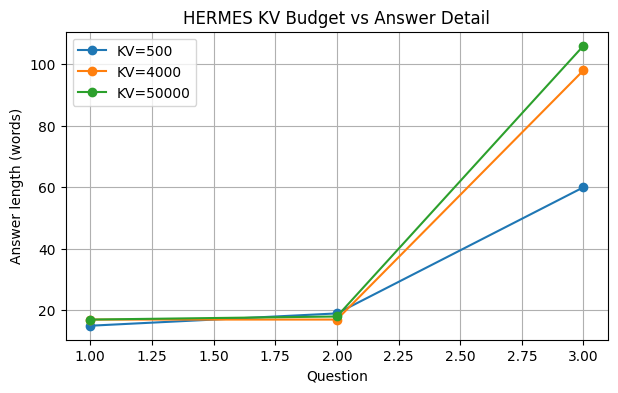

In [17]:
import matplotlib.pyplot as plt

lengths = {}

for name, df in results.items():
    lengths[name] = [
        len(str(x).split())
        for x in df["pred_answer"]
    ]

plt.figure(figsize=(7,4))

for name, vals in lengths.items():
    plt.plot(
        range(1, len(vals)+1),
        vals,
        marker="o",
        label=name
    )

plt.xlabel("Question")
plt.ylabel("Answer length (words)")
plt.title("HERMES KV Budget vs Answer Detail")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
%cd /kaggle/working/HERMES

!CUDA_VISIBLE_DEVICES=0 \
python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_500 \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 500 \
    --streaming true \
    2>&1 | tee logs_kv500.txt

/kaggle/working/HERMES
[I 260916 10:04:54 base:273] seed: 2024
[I 260916 10:04:54 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 10:04:57 llavaov_hermes:941] n_init: 13
[I 260916 10:04:57 llavaov_hermes:942] kv_size: 500
  0%|          | 0/1 [00:00<?, ?it/s][D 260916 10:04:57 base:232] video_id: kaggle_test_001

  0%|          | 0/3 [00:00<?, ?it/s][D 260916 10:04:59 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
[I 260916 10:05:00 hermes_vqa:61] Triggering question prediction and KV compression
[I 260916 10:05:00 llavaov_hermes:288] Layer-wise shrink completed. Lengths: min=513, max=513, first=513, last=513
[I 260916 10:05:00 llavaov_hermes:408] Strict-shrunk KV cache. New length: 513
[I 260916 10:05:01 llavaov_hermes:863] Saved conversation to history. Total conversations: 1

 

In [21]:
!CUDA_VISIBLE_DEVICES=0 \
python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_4000 \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 4000 \
    --streaming true \
    2>&1 | tee logs_kv4000.txt

[I 260916 10:05:33 base:273] seed: 2024
[I 260916 10:05:33 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 10:05:36 llavaov_hermes:941] n_init: 13
[I 260916 10:05:36 llavaov_hermes:942] kv_size: 4000
  0%|          | 0/1 [00:00<?, ?it/s][D 260916 10:05:36 base:232] video_id: kaggle_test_001

  0%|          | 0/3 [00:00<?, ?it/s][D 260916 10:05:38 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
[I 260916 10:05:39 hermes_vqa:61] Triggering question prediction and KV compression
[I 260916 10:05:40 llavaov_hermes:863] Saved conversation to history. Total conversations: 1

 33%|███▎      | 1/3 [00:02<00:04,  2.11s/it][D 260916 10:05:40 hermes_vqa:44] sample: {'question': 'What is the person doing at this point in the video?', 'answer': '', 'end_time': 62.24885333333334, 'task': 'Action 

In [22]:
!CUDA_VISIBLE_DEVICES=0 \
python -m video_qa.hermes_vqa \
    --model llava_ov_0.5b \
    --sample_fps 0.5 \
    --save_dir results/kaggle_50000 \
    --anno_path data/kaggle_smoke.json \
    --debug true \
    --num_chunks 1 \
    --chunk_idx 0 \
    --kv_size 50000 \
    --streaming true \
    2>&1 | tee logs_kv50000.txt

[I 260916 10:06:12 base:273] seed: 2024
[I 260916 10:06:12 base:278] Loading VideoQA model: models/llava-onevision-qwen2-0.5b-ov-hf
[I 260916 10:06:15 llavaov_hermes:941] n_init: 13
[I 260916 10:06:15 llavaov_hermes:942] kv_size: 50000
  0%|          | 0/1 [00:00<?, ?it/s][D 260916 10:06:15 base:232] video_id: kaggle_test_001

  0%|          | 0/3 [00:00<?, ?it/s][D 260916 10:06:17 hermes_vqa:44] sample: {'question': 'What is happening in the video right now?', 'answer': '', 'end_time': 28.294933333333333, 'task': 'Action Recognition', 'time_stamp': '00:00:00', 'required_ability': 'working memory'}
[I 260916 10:06:18 hermes_vqa:61] Triggering question prediction and KV compression
[I 260916 10:06:19 llavaov_hermes:863] Saved conversation to history. Total conversations: 1

 33%|███▎      | 1/3 [00:02<00:04,  2.15s/it][D 260916 10:06:19 hermes_vqa:44] sample: {'question': 'What is the person doing at this point in the video?', 'answer': '', 'end_time': 62.24885333333334, 'task': 'Action

In [23]:
import re
import pandas as pd
from pathlib import Path


log_files = {
    "KV=500": "logs_kv500.txt",
    "KV=4000": "logs_kv4000.txt",
    "KV=50000": "logs_kv50000.txt",
}


records = []


for name, file in log_files.items():

    if not Path(file).exists():
        print("Missing:", file)
        continue

    text = Path(file).read_text()

    record = {
        "setting": name,
        "kv_size": int(
            re.search(
                r"kv_size:\s*(\d+)",
                text
            ).group(1)
        )
        if re.search(r"kv_size:\s*(\d+)", text)
        else None,

        "compression_triggered":
            "Applying KV-Cache compression" in text,

        "memory_gb":
            None,

        "compressed_length":
            None,

        "ttft_seconds":
            None
    }


    # GPU memory
    mem = re.findall(
        r"GPU memory usage:\s*([0-9.]+)",
        text
    )

    if mem:
        record["memory_gb"] = max(
            float(x) for x in mem
        )


    # compressed cache length
    cache = re.findall(
        r"Strict-shrunk KV cache\. New length:\s*(\d+)",
        text
    )

    if cache:
        record["compressed_length"] = int(cache[-1])


    # TTFT
    ttft = re.findall(
        r"TTFT:\s*([0-9.]+)",
        text
    )

    if ttft:
        record["ttft_seconds"] = float(ttft[-1])


    records.append(record)


df = pd.DataFrame(records)

df

,setting,kv_size,compression_triggered,memory_gb,compressed_length,ttft_seconds
0,KV=500,500,True,4.435410,513.0,0.060181
1,KV=4000,4000,True,4.518743,4013.0,0.060793
2,KV=50000,50000,False,4.584764,NaN,0.072614


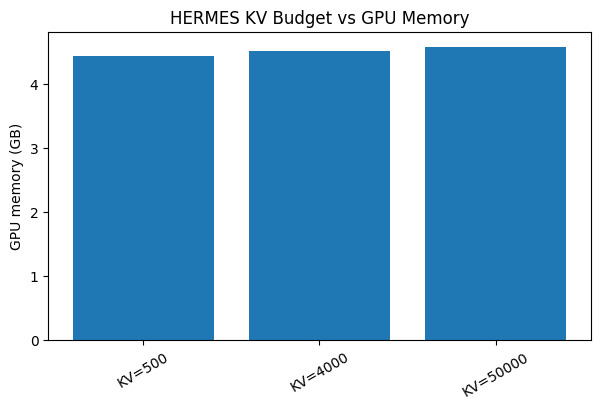

In [24]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))

plt.bar(
    df["setting"],
    df["memory_gb"]
)

plt.ylabel("GPU memory (GB)")
plt.title("HERMES KV Budget vs GPU Memory")

plt.xticks(rotation=30)

plt.show()

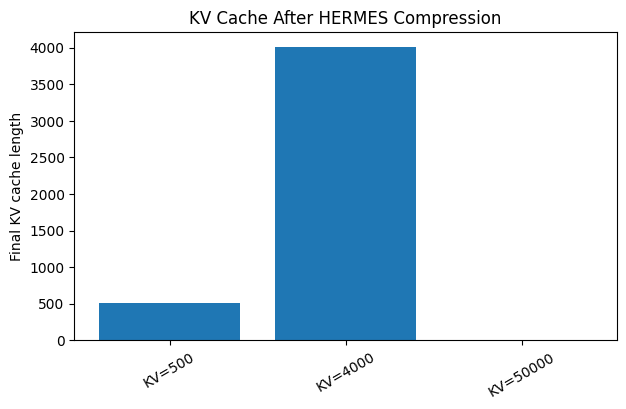

In [25]:
plt.figure(figsize=(7,4))

plt.bar(
    df["setting"],
    df["compressed_length"].fillna(0)
)

plt.ylabel("Final KV cache length")
plt.title("KV Cache After HERMES Compression")

plt.xticks(rotation=30)

plt.show()

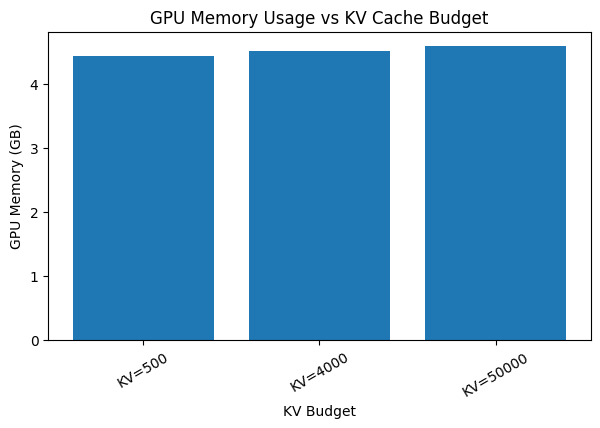

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    df["setting"],
    df["memory_gb"]
)

plt.ylabel("GPU Memory (GB)")
plt.xlabel("KV Budget")
plt.title("GPU Memory Usage vs KV Cache Budget")

plt.xticks(rotation=30)
plt.show()

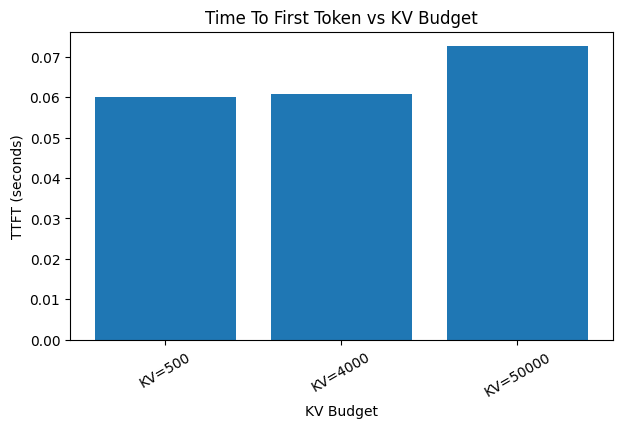

In [27]:
plt.figure(figsize=(7,4))

plt.bar(
    df["setting"],
    df["ttft_seconds"]
)

plt.ylabel("TTFT (seconds)")
plt.xlabel("KV Budget")
plt.title("Time To First Token vs KV Budget")

plt.xticks(rotation=30)
plt.show()


# Reproduction Checklist

## Completed
- [x] LLaVA-OneVision-0.5B loading
- [x] Streaming frame processing
- [x] HERMES pseudo-question generation
- [x] KV-cache compression
- [x] Fixed-budget cache experiments

## KV Cache Budget Experiment Results

HERMES was evaluated with three KV-cache budgets:

- KV=500 (aggressive compression)
- KV=4000 (paper-style setting)
- KV=50000 (near-uncompressed control)

Results show that HERMES successfully maintains bounded KV-cache sizes:

- KV=500 produced a final cache length of 513 tokens.
- KV=4000 produced a final cache length of 4013 tokens.
- KV=50000 did not trigger compression.

GPU memory usage remained stable across settings (~4.4–4.6 GB), demonstrating bounded memory behavior during streaming inference.

The experiment confirms that the HERMES KV compression mechanism is functioning correctly on the Kaggle T4 environment.

## Next Research Stage
StreamingBench evaluation:

1. Download official StreamingBench videos
2. Replace video paths
3. Run KV=4000 and KV=6000
4. Compute benchmark accuracy

Custom sandwich video
        ✅ completed

KV budget analysis
        ✅ completed

StreamingBench evaluation
        ⬅ next
